In [1]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 25.7 MB/s eta 0:00:0000:01
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993331 sha256=f1fcf018da764049a84c90833a93062bc2c9d2c21b84c6161bbf076f6df5d40a
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from langdetect import detect, DetectorFactory

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/joykimaiyo18/linkedin-data-jobs-dataset/clean_jobs.csv


In [3]:
# 1. Load the dataset
file_path = '/kaggle/input/datasets/joykimaiyo18/linkedin-data-jobs-dataset/clean_jobs.csv'
df = pd.read_csv(file_path)

# Ensure consistent language detection
DetectorFactory.seed = 42

# Initial exploration: check dimensions
print(f"Original dataset dimensions: {df.shape}")

text_column = 'description' 
df = df.dropna(subset=[text_column]) 
print(f"Dimensions after removing null values: {df.shape}")

# 2. Language Detection Filter (Keep ONLY English postings)
def is_english(text):
    try:
        return detect(text) == 'en'
    except:
        return False

print("Filtering non-English job postings. This might take a minute...")
# Apply the filter and keep only English rows
df = df[df[text_column].apply(is_english)].copy()
print(f"Dimensions after English-only filter: {df.shape}")

# 3. Expanded Custom Stop-Words (Removing HR jargon and boilerplate)
custom_stop_words = [
    # General Data/Job terms
    'data', 'science', 'scientist', 'engineer', 'engineering', 
    'machine', 'learning', 'ai', 'artificial', 'intelligence', 'junior', 'senior',
    'work', 'experience', 'team', 'company', 'role', 'job', 
    'looking', 'required', 'skills', 'years', 'business', 'opportunity',
    'working', 'knowledge', 'understanding', 'support', 'development',
    
    # HR & Boilerplate terms from Cluster 3
    'benefits', 'time', 'paid', 'information', 'employees', 'including', 
    'status', 'range', 'compensation', 'position', 'salary', 'pay', 
    'hire', 'hiring', 'equal', 'employer', 'gender', 'sexual', 'orientation', 
    'disability', 'veteran', 'religion', 'law', 'medical', 'dental', 'vision',
    'vacation', 'leave', 'applicant', 'applicants', 'employment', 'opportunity',
    
    # Meta / Corporate fluff from Cluster 0
    'meta', 'product', 'people', 'build', 'accommodations', 'screens', 
    'applicable', 'connect', 'help', 'bonus', 'equity', 'facebook', 'world',
    'bring', 'make', 'life', 'impact', 'join', 'inclusive', 'environment'
]

# Combine standard English stop-words with our expanded list
all_stop_words = list(ENGLISH_STOP_WORDS.union(custom_stop_words))

# 4. Text cleaning function using RegEx
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)  # Keep only letters
    text = text.lower()                      # Convert to lowercase
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    return text

# 5. Apply the cleaning function
print("Starting deep text cleaning...")
df['clean_desc'] = df[text_column].apply(clean_text)
print("Cleaning successfully completed! Ready for TF-IDF.")

Original dataset dimensions: (1048, 10)
Dimensions after removing null values: (1044, 10)
Filtering non-English job postings. This might take a minute...
Dimensions after English-only filter: (969, 10)
Starting deep text cleaning...
Cleaning successfully completed! Ready for TF-IDF.


Starting TF-IDF vectorization...
TF-IDF Matrix shape: (969, 1000)
Calculating Inertia for the Elbow Method. This may take a while depending on dataset size...


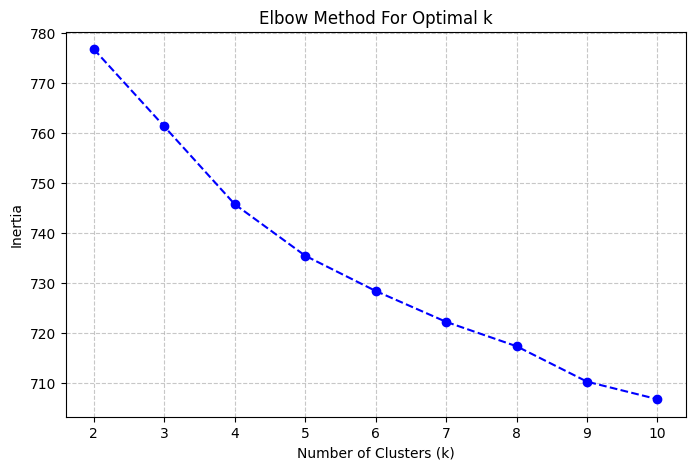

In [4]:
# 1. Feature Extraction with TF-IDF
print("Starting TF-IDF vectorization...")
# Use max_features to limit the vocabulary to the top 1000 most relevant n-grams (1 or 2 words)
vectorizer = TfidfVectorizer(stop_words=all_stop_words, max_features=1000, ngram_range=(1, 2))
X = vectorizer.fit_transform(df['clean_desc'])
print(f"TF-IDF Matrix shape: {X.shape}")

# 2. Optimizing the number of clusters (k) using the Elbow Method
print("Calculating Inertia for the Elbow Method. This may take a while depending on dataset size...")
inertia = []
K_range = range(2, 11) # Testing k from 2 to 10

# Iterate through different values of k to find the optimal number of clusters
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# 3. Plotting the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Looking at the Inertia curve, the inflection point (the actual "elbow") occurs at k=5. Beyond the value of 5, the curve's descent becomes nearly linear and ceases to drop sharply. This indicates mathematically that the algorithm has identified five distinct professional macro-profiles within the labor market.

Training final KMeans model with 5 clusters...
Applying PCA to reduce dimensions for plotting...


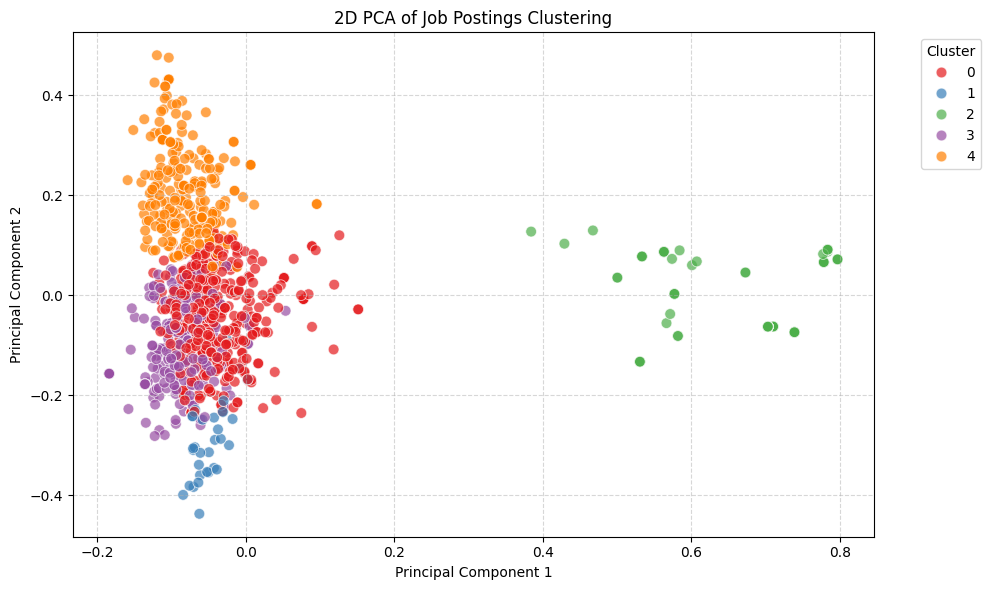

In [5]:
# Block 3: Final Clustering and PCA

# 1. Set the optimal number of clusters based on the Elbow Method
optimal_k = 5
print(f"Training final KMeans model with {optimal_k} clusters...")

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X)

# 2. Dimensionality Reduction using PCA for 2D Visualization
print("Applying PCA to reduce dimensions for plotting...")
X_dense = X.toarray() # Convert sparse matrix to dense for PCA
pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(X_dense)

# Add PCA components back to the dataframe
df['pca_1'] = components[:, 0]
df['pca_2'] = components[:, 1]

# 3. Plotting the clusters
plt.figure(figsize=(10, 6))
# Using a distinct color palette for the 3 clusters
sns.scatterplot(x='pca_1', y='pca_2', hue='cluster', palette='Set1', data=df, s=60, alpha=0.7)
plt.title('2D PCA of Job Postings Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Clusters 0, 1, 3, and 4 are relatively close to one another, likely representing the more classic nuances of data analysis. Cluster 2 (the green points) is completely detached from the others, isolated at the far right of Principal Component 1. In Natural Language Processing, when a group is projected this far away, it indicates that its technical vocabulary is highly specialized and drastically different from the rest of the market.

Generating Top Words plots for each cluster...


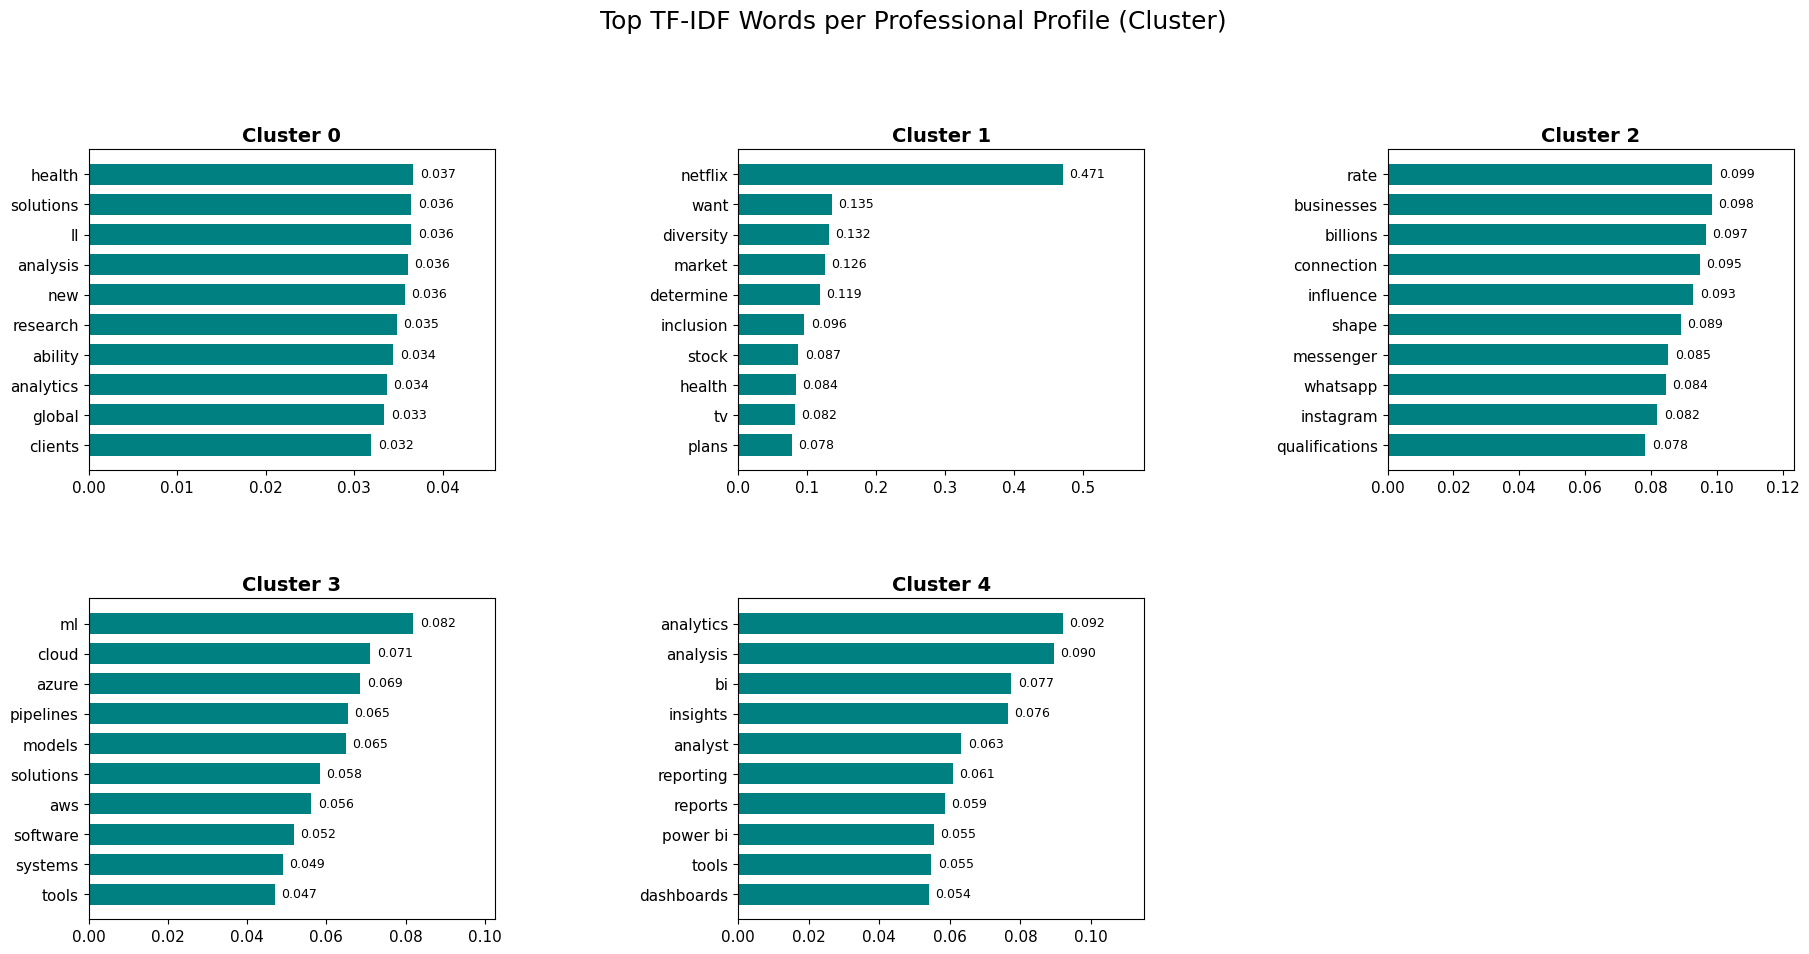

In [6]:
# Block 4: Extracting Top Words per Cluster 
import math
import matplotlib.pyplot as plt

def plot_top_words(model, feature_names, n_top_words=10):
    """
    Function to extract and plot the highest TF-IDF weight words for each cluster.
    Dynamically adjusts the grid size based on the number of clusters.
    """
    n_clusters = len(model.cluster_centers_)
    cols = 3
    # Calculate the number of rows needed
    rows = math.ceil(n_clusters / cols)
    
    # Create the dynamic grid 
    fig, axes = plt.subplots(rows, cols, figsize=(22, 5 * rows), sharex=False)
    axes = axes.flatten()
    
    for topic_idx, topic in enumerate(model.cluster_centers_):
        # Sort the cluster center weights to find the top words
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        # Plot the horizontal bar chart
        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7, color='teal')
        ax.set_title(f'Cluster {topic_idx}', fontdict={'fontsize': 14, 'fontweight': 'bold'})
        ax.invert_yaxis() # Display the highest weight at the top
        ax.tick_params(axis='both', which='major', labelsize=11)
        max_weight = max(weights)
        ax.set_xlim(0, max_weight + (max_weight * 0.25))
        
        for i, v in enumerate(weights):
            ax.text(v + (max_weight * 0.02), i + 0.1, f'{v:.3f}', color='black', fontsize=9)

    # Hide any unused subplots
    for i in range(n_clusters, len(axes)):
        fig.delaxes(axes[i])
        
    plt.subplots_adjust(top=0.82, bottom=0.05, wspace=0.6, hspace=0.4)
    plt.suptitle('Top TF-IDF Words per Professional Profile (Cluster)', fontsize=18, y=0.96)
    plt.show()

# Get the vocabulary features from the vectorizer
feature_names = vectorizer.get_feature_names_out()

# Execute the plotting function
print("Generating Top Words plots for each cluster...")
plot_top_words(kmeans_final, feature_names, n_top_words=10)

In the labor market, large companies (Big Tech) publish such a massive volume of job postings using such standardized formatting—that they create distinct clusters of their own.

Cluster 1 (The Netflix profile): Dominated by terms such as Netflix, TV, and market, interspersed with corporate boilerplate (diversity, inclusion).

Cluster 2 (The Meta profile): Instantly recognizable. The algorithm isolated all positions linked to Mark Zuckerberg’s ecosystem thanks to words like WhatsApp, Instagram, Messenger, and billions.

The algorithm split the data landscape in two, confirming the hypothesis of a polarization of skill sets.

Cluster 4 (The Business/BI Analyst): Keywords include dashboards, reports, BI, insights, and marketing. This represents the classic Data Analyst: a role focused on reporting, extracting descriptive metrics, and supporting business decision-making. It is a role that is far less algorithmic and far more relationship-oriented.

Cluster 3 (The MLOps/AI Engineer): Keywords include ML, cloud, Azure, AWS, pipelines, and models. The algorithm isolated roles that are heavily engineering-focused. This profile belongs to someone who does not merely analyze data but deploys Machine Learning models into production and builds advanced architectures. It is precisely the kind of technical, specialized role an AI Engineer would fill.

Cluster 0 (The Researcher / Manager): Terms such as research, health, analysis, and management. This appears to be a hybrid cluster, perhaps focused on managerial roles within the research sector (e.g., pharmaceuticals or academia), where analytical skills merge with project management.

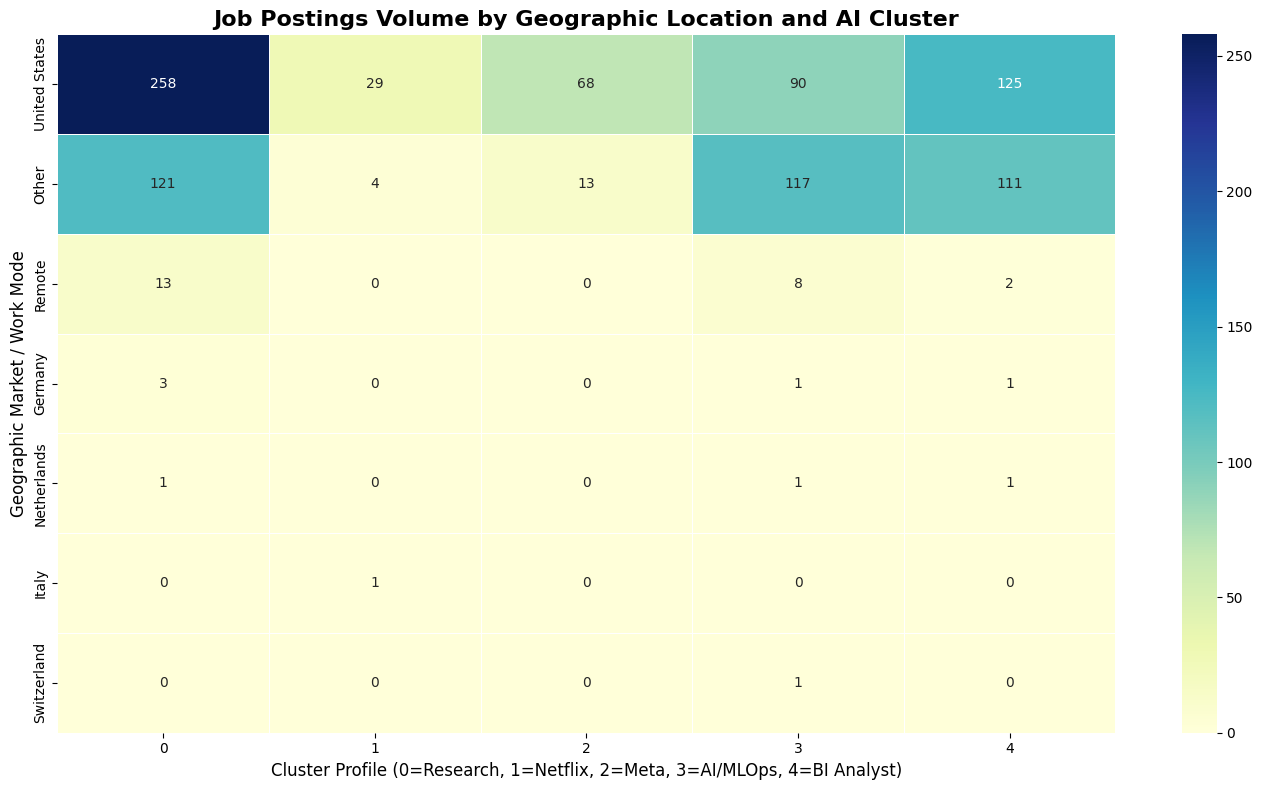

In [9]:
# Block 5: Geographic and Experience Level Distribution

# Geographic Distribution (Heatmap)
location_col = 'location' 

if location_col in df.columns:
    
    def categorize_location(loc_string):
        if not isinstance(loc_string, str):
            return 'Other'
            
        loc_lower = loc_string.lower()
        
        # 1. Catch Remote Work (The massive 45% chunk)
        if 'remote' in loc_lower:
            return 'Remote'
            
        # 2. Catch United States (Handles "City, ST" format like "Boca Raton, FL")
        # Regex looks for a comma, optional space, and exactly 2 uppercase letters at the end
        if 'united states' in loc_lower or 'usa' in loc_lower or re.search(r',\s*[A-Z]{2}$', str(loc_string)):
            return 'United States'
            
        # 4. Target European Markets 
        if 'netherlands' in loc_lower or 'holland' in loc_lower or 'amsterdam' in loc_lower:
            return 'Netherlands'
        if 'italy' in loc_lower or 'italia' in loc_lower or 'milan' in loc_lower or 'rome' in loc_lower:
            return 'Italy'
        if 'germany' in loc_lower or 'berlin' in loc_lower or 'munich' in loc_lower:
            return 'Germany'
        if 'switzerland' in loc_lower or 'swiss' in loc_lower or 'zurich' in loc_lower or 'geneva' in loc_lower or 'suisse' in loc_lower:
            return 'Switzerland'
            
        return 'Other'

    # Apply the advanced categorization
    df['country_group'] = df[location_col].apply(categorize_location)
    
    # Generate the Cross-Tabulation
    plt.figure(figsize=(14, 8))
    crosstab_loc = pd.crosstab(df['country_group'], df['cluster'])
    
    # Sort by total volume to make the heatmap look cleaner (Remote and US will likely be top)
    crosstab_loc['Total'] = crosstab_loc.sum(axis=1)
    crosstab_loc = crosstab_loc.sort_values(by='Total', ascending=False).drop('Total', axis=1)
    
    # Plotting the heatmap
    sns.heatmap(crosstab_loc, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)
    plt.title('Job Postings Volume by Geographic Location and AI Cluster', fontsize=16, fontweight='bold')
    plt.xlabel('Cluster Profile (0=Research, 1=Netflix, 2=Meta, 3=AI/MLOps, 4=BI Analyst)', fontsize=12)
    plt.ylabel('Geographic Market / Work Mode', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print(f"Warning: Column '{location_col}' not found. Please check spelling.")